In [61]:
# loading Dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [62]:
# loading dataset
df = pd.read_csv('nba-players.csv.csv')

In [31]:
df.head()

,Unnamed: 0,name,gp,min,pts,fgm,fga,fg,3p_made,3pa,...,fta,ft,oreb,dreb,reb,ast,stl,blk,tov,target_5yrs
0,0,Brandon Ingram,36,27.4,7.4,2.6,7.6,34.7,0.5,2.1,...,2.3,69.9,0.7,3.4,4.1,1.9,0.4,0.4,1.3,0
1,1,Andrew Harrison,35,26.9,7.2,2.0,6.7,29.6,0.7,2.8,...,3.4,76.5,0.5,2.0,2.4,3.7,1.1,0.5,1.6,0
2,2,JaKarr Sampson,74,15.3,5.2,2.0,4.7,42.2,0.4,1.7,...,1.3,67.0,0.5,1.7,2.2,1.0,0.5,0.3,1.0,0
3,3,Malik Sealy,58,11.6,5.7,2.3,5.5,42.6,0.1,0.5,...,1.3,68.9,1.0,0.9,1.9,0.8,0.6,0.1,1.0,1
4,4,Matt Geiger,48,11.5,4.5,1.6,3.0,52.4,0.0,0.1,...,1.9,67.4,1.0,1.5,2.5,0.3,0.3,0.4,0.8,1


In [32]:
# Defining target
y = df['target_5yrs']

In [33]:
#Features
X = df.drop('target_5yrs', axis=1)
print("Target Variable:", y.name)

Target Variable: target_5yrs


## Target Variable
the column 'target_5yrs' is selected as the dependent variable.
It indicates whether an NBA player remained in the league for at least five years.

In [34]:
# Drop Index and player name
X = X.drop(['Unnamed: 0', 'name'], axis=1)
print(X.shape)

(1340, 19)


## Removing Non-Predictive Features
the column 'Unnamed: 0' and 'name' were removed because they do not contribute to predicting player longevity and may introduce noise

In [35]:
# checking missing values
print(X.isnull().sum())

gp         0
min        0
pts        0
fgm        0
fga        0
fg         0
3p_made    0
3pa        0
3p         0
ftm        0
fta        0
ft         0
oreb       0
dreb       0
reb        0
ast        0
stl        0
blk        0
tov        0
dtype: int64


In [36]:
X =X.fillna(X.median(numeric_only=True))

## Handling Missing Values
Missing values were replaced using the median of each numerical feature.
Median imputation is robust to outliers and preserves the distribution of the data

In [46]:
# Correlation Analysis
corr_matrix = X.corr().abs()
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)
high_corr = [
    column for column in upper.columns
    if any(upper[column] > 0.90)
]
print("Highly correlated columns:", high_corr)

Highly correlated columns: ['pts', 'fgm', 'fga', '3pa', 'fta', 'reb', 'efficiency_rating', 'assist_to_turnover_ratio']


In [47]:
# remove one correlated feature to reduce multicollinearity
if 'gp' in X.columns:
    X = X.drop(columns=['gp'])
print("Remaining Features:", X.shape[1])    

Remaining Features: 21


In [57]:
print(X.columns)

Index(['min', 'pts', 'fgm', 'fga', 'fg', '3p_made', '3pa', '3p', 'ftm', 'fta',
       'ft', 'oreb', 'dreb', 'reb', 'ast', 'stl', 'blk', 'tov',
       'points_per_minute', 'efficiency_rating', 'assist_to_turnover_ratio',
       'defensive_activity'],
      dtype='object')


### Correlation Analysis
Correlation analysis showed that **gp** and **min** are highly correlated.
To reduce multicollinearity,the **gp** column was removed while **min** was retained because it better represents a player's actual time on the court.

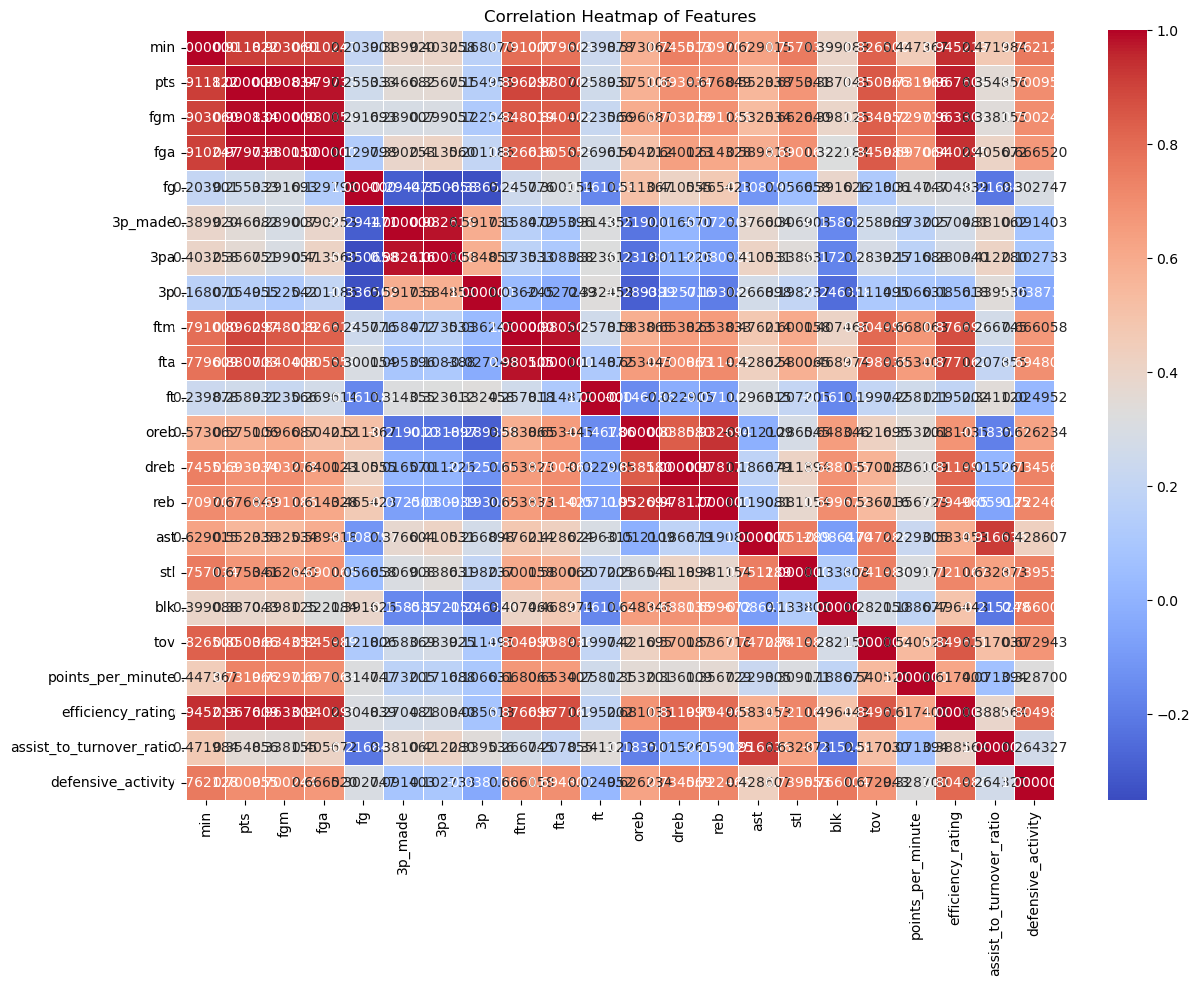

In [67]:
## compute correlation matrix 
corr_matrix = X.corr()
# plot heatmap
plt.figure(figsize=(14,10))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt='2f', linewidths=0.5)
plt.title("Correlation Heatmap of Features")
plt.show()

### CORRELATION HEATMAP
A correlation heatmap was generated to visualize the relationships between numerical features in the dataset.
Feature withhigh positive or negative correlations were identified to detect multicollinearity. Based on the analysis,redundant features were removed to improve model performance and reduce overfitting.

In [53]:
# FEATURE ENGINEERING
#Assist-to-Turnover Ratio
X['assist_to_turnover_ratio'] = X['ast'] / (X['tov'] + 1)
X[['assist_to_turnover_ratio']].head()

,assist_to_turnover_ratio
0,0.826087
1,1.423077
2,0.500000
3,0.400000
4,0.166667


In [55]:
# Defensive Activity
X['defensive_activity'] = X['stl'] + X['blk']

In [59]:
# Checking
X[['assist_to_turnover_ratio', 'defensive_activity']].head()

,assist_to_turnover_ratio,defensive_activity
0,0.826087,0.8
1,1.423077,1.6
2,0.500000,0.8
3,0.400000,0.7
4,0.166667,0.7


### FEATURE ENGINEERING
A new feature called **assist_to_turnover_ratio** was created by dividing assists by turnovers plus one.
This feature measures how efficiently a player creates scoring opportunities while minimizing turnovers.It provides additional information beyond the original variables and may improve model performance.

In [69]:
# VERIFYING THE ENGINEERED FEATURES
print(X[['points_per_minute',
        'efficiency_rating',
        'assist_to_turnover_ratio']] .head())

   points_per_minute  efficiency_rating  assist_to_turnover_ratio
0           0.260563               12.9                  0.826087
1           0.258065               13.3                  1.423077
2           0.319018                8.2                  0.500000
3           0.452381                8.1                  0.400000
4           0.360000                7.2                  0.166667


In [71]:
#SAVE THE FINAL DATASET
#creating the final dataset
final_df = pd.concat([X, y], axis=1)
#checkig the first five rows
print(final_df.head())

    min  pts  fgm  fga    fg  3p_made  3pa    3p  ftm  fta  ...  reb  ast  \
0  27.4  7.4  2.6  7.6  34.7      0.5  2.1  25.0  1.6  2.3  ...  4.1  1.9   
1  26.9  7.2  2.0  6.7  29.6      0.7  2.8  23.5  2.6  3.4  ...  2.4  3.7   
2  15.3  5.2  2.0  4.7  42.2      0.4  1.7  24.4  0.9  1.3  ...  2.2  1.0   
3  11.6  5.7  2.3  5.5  42.6      0.1  0.5  22.6  0.9  1.3  ...  1.9  0.8   
4  11.5  4.5  1.6  3.0  52.4      0.0  0.1   0.0  1.3  1.9  ...  2.5  0.3   

   stl  blk  tov  points_per_minute  efficiency_rating  \
0  0.4  0.4  1.3           0.260563               12.9   
1  1.1  0.5  1.6           0.258065               13.3   
2  0.5  0.3  1.0           0.319018                8.2   
3  0.6  0.1  1.0           0.452381                8.1   
4  0.3  0.4  0.8           0.360000                7.2   

   assist_to_turnover_ratio  defensive_activity  target_5yrs  
0                  0.826087                 0.8            0  
1                  1.423077                 1.6            0  

In [72]:
# Save the processed dataset
final_df.to_csv('nba_feature_engineered.csv', index=False)

print("Dataset saved successfully!")

Dataset saved successfully!


In [73]:
# Load the saved dataset
saved_df = pd.read_csv('nba_feature_engineered.csv')

In [74]:
# Display the first five row
print(saved_df.head())

    min  pts  fgm  fga    fg  3p_made  3pa    3p  ftm  fta  ...  reb  ast  \
0  27.4  7.4  2.6  7.6  34.7      0.5  2.1  25.0  1.6  2.3  ...  4.1  1.9   
1  26.9  7.2  2.0  6.7  29.6      0.7  2.8  23.5  2.6  3.4  ...  2.4  3.7   
2  15.3  5.2  2.0  4.7  42.2      0.4  1.7  24.4  0.9  1.3  ...  2.2  1.0   
3  11.6  5.7  2.3  5.5  42.6      0.1  0.5  22.6  0.9  1.3  ...  1.9  0.8   
4  11.5  4.5  1.6  3.0  52.4      0.0  0.1   0.0  1.3  1.9  ...  2.5  0.3   

   stl  blk  tov  points_per_minute  efficiency_rating  \
0  0.4  0.4  1.3           0.260563               12.9   
1  1.1  0.5  1.6           0.258065               13.3   
2  0.5  0.3  1.0           0.319018                8.2   
3  0.6  0.1  1.0           0.452381                8.1   
4  0.3  0.4  0.8           0.360000                7.2   

   assist_to_turnover_ratio  defensive_activity  target_5yrs  
0                  0.826087                 0.8            0  
1                  1.423077                 1.6            0  

### CONCLUSION
The feature engineering pipeline successfully prepared the dataset for machine learning.
### STEPS COMLETED
- Defined 'target_5yrs' as the target variable.
- Removed non-predictive columns ('name' and 'Unnamed: 0').
- Handled missing values using median imputation.
- Performed correlation analysis.
- Reduced multicollinearity by removing the 'gp' feature.
- Created two new engineered features:
-  **Assist-to-Turnover Ratio**
-  **Defensive Activity**
-  Produced a clean dataset ready for machine learning.
These engineered features capture player efficiency and defensive impact,which may improve the prediction of whether a player remains in the NBA for at least five years.